<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Aula 3: Regressão Polinomial com Gradiente Descendente</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/NumPy-013243?style=for-the-badge&logo=numpy&logoColor=white"/>
</div>

---

## <span style="color:#1E90FF;">Contexto</span>

| Aula | O que fizemos |
|---|---|
| **Aula 0** | Encontramos a reta escolhendo **dois pontos manualmente** (triângulo) |
| **Aula 1** | Construímos o algoritmo de **gradiente descendente** com NumPy |
| **Aula 2** | Aplicamos o gradiente ao trocador de calor — comparamos com o triângulo |
| **Aula 3 (esta)** | Generalizamos o gradiente para **polinômios de qualquer grau** |

Nas aulas anteriores ajustamos apenas **retas** ($y = \theta_0 + \theta_1 x$). Mas e quando os dados seguem uma curva?

Nesta aula vamos estender o algoritmo para que o usuário possa escolher o **grau do modelo** — 1º, 2º ou 3º — e o gradiente descendente encontrará os melhores coeficientes automaticamente.

**Restrição:** somente **NumPy** — sem sklearn, scipy ou outras bibliotecas de ML.

---
## <span style="color:#1E90FF;">1. O Problema — Dados Não-Lineares</span>

Vamos gerar um conjunto de dados sintético a partir de um polinômio **cúbico** com ruído gaussiano:

$$y = 0.5x^3 - 1.5x^2 + x + 2 + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0,\, 1)$$

Uma reta não consegue capturar essa relação — precisamos de um modelo de grau superior.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Dados sintéticos ─────────────────────────────────────────────────────
np.random.seed(42)
n = 120
X = np.linspace(-3, 3, n)
y_true = 0.5 * X**3 - 1.5 * X**2 + X + 2
y = y_true + np.random.normal(0, 1.0, n)

# ── Visualização ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(X, y, s=15, alpha=0.5, color='green', label='Dados com ruído', zorder=2)
ax.plot(X, y_true, 'k--', linewidth=1.5, alpha=0.7, label='Curva real (sem ruído)', zorder=1)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Dados Sintéticos — Polinômio Cúbico com Ruído')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## <span style="color:#1E90FF;">2. Expansão de Features Polinomiais</span>

A ideia central é **transformar** a entrada escalar $x$ em um vetor de features:

$$\phi(x) = \begin{bmatrix} 1 \\ x \\ x^2 \\ \vdots \\ x^p \end{bmatrix}$$

e depois usar regressão linear sobre esse vetor estendido. Para $n$ amostras, montamos a **matriz de design** $\Phi$:

$$\Phi = \begin{bmatrix}
1 & x_1 & x_1^2 & \cdots & x_1^p \\
1 & x_2 & x_2^2 & \cdots & x_2^p \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_n & x_n^2 & \cdots & x_n^p
\end{bmatrix} \in \mathbb{R}^{n \times (p+1)}$$

A predição passa a ser:

$$\hat{y} = \Phi\,\theta \qquad \theta = [\theta_0,\, \theta_1,\, \ldots,\, \theta_p]^\top$$

In [2]:
def construir_features(X, grau):
    """
    Constrói a matriz de design Φ com colunas polinomiais.

    Parâmetros
    ----------
    X    : array (n,) — entrada (deve estar normalizada antes de chamar)
    grau : int        — grau máximo do polinômio (1, 2 ou 3)

    Retorna
    -------
    Phi : array (n, grau+1) — colunas [1, x, x², ..., x^grau]
    """
    n = len(X)
    Phi = np.ones((n, grau + 1))
    for d in range(1, grau + 1):
        Phi[:, d] = X ** d
    return Phi


# Exemplo: 5 primeiras linhas para grau=3
X_norm_ex = (X - X.mean()) / X.std()
Phi_ex = construir_features(X_norm_ex, grau=3)
print("Matriz Φ (5 primeiras linhas, grau=3):")
print(f"  {'bias':>8}  {'x':>8}  {'x²':>8}  {'x³':>8}")
print("  " + "─" * 38)
for row in Phi_ex[:5]:
    print("  " + "  ".join(f"{v:+8.4f}" for v in row))

Matriz Φ (5 primeiras linhas, grau=3):
      bias         x        x²        x³
  ──────────────────────────────────────
   +1.0000   -1.7177   +2.9504   -5.0679
   +1.0000   -1.6888   +2.8521   -4.8166
   +1.0000   -1.6599   +2.7554   -4.5738
   +1.0000   -1.6311   +2.6604   -4.3393
   +1.0000   -1.6022   +2.5671   -4.1129


---
## <span style="color:#1E90FF;">3. Normalização das Features</span>

Colunas com escalas muito diferentes causam gradientes desequilibrados e convergência lenta. Normalizamos cada coluna (exceto o **bias**):

$$\tilde{\phi}_j = \frac{\phi_j - \mu_j}{\sigma_j}, \qquad j = 1, \ldots, p$$

Isso **não altera o poder de representação** do modelo — apenas estabiliza a convergência do gradiente descendente.

In [3]:
def normalizar_features(Phi):
    """
    Normaliza as colunas de features de Phi (coluna de bias permanece intacta).

    Parâmetros
    ----------
    Phi : array (n, d) — matriz de design original

    Retorna
    -------
    Phi_norm : array (n, d) — matriz com colunas 1..d-1 normalizadas
    """
    Phi_norm = Phi.copy().astype(float)
    for j in range(1, Phi.shape[1]):       # coluna 0 é o bias — não mexe
        mu    = Phi[:, j].mean()
        sigma = Phi[:, j].std() + 1e-8     # evita divisão por zero
        Phi_norm[:, j] = (Phi[:, j] - mu) / sigma
    return Phi_norm


print("Função `normalizar_features` implementada.")

Função `normalizar_features` implementada.


---
## <span style="color:#1E90FF;">4. Gradiente Descendente Vetorizado</span>

Com a matriz $\Phi$, todas as operações ficam compactas em álgebra linear.

**Loss (MSE):**

$$\mathcal{L}(\theta) = \frac{1}{n} \|\Phi\theta - y\|^2$$

**Gradiente (derivada vetorial):**

$$\nabla_\theta\, \mathcal{L} = \frac{2}{n}\, \Phi^\top (\Phi\theta - y)$$

**Atualização dos parâmetros:**

$$\theta \leftarrow \theta - \alpha \cdot \nabla_\theta\, \mathcal{L}$$

Independente do grau escolhido, o algoritmo é **exatamente o mesmo** — apenas $\Phi$ muda de tamanho.

In [4]:
def gradiente_descendente(Phi, y, alpha=0.05, n_iter=3000):
    """
    Regressão polinomial por gradiente descendente (forma vetorizada).

    Parâmetros
    ----------
    Phi    : array (n, d) — matriz de design normalizada
    y      : array (n,)   — valores alvo
    alpha  : float        — taxa de aprendizado
    n_iter : int          — número de iterações

    Retorna
    -------
    theta     : array (d,) — coeficientes treinados
    historico : list       — MSE a cada iteração
    """
    n, d = Phi.shape
    theta = np.zeros(d)
    historico = []

    for _ in range(n_iter):
        residuo = Phi @ theta - y               # erro atual:  (n,)
        mse = np.mean(residuo ** 2)             # loss
        historico.append(mse)
        grad = (2 / n) * (Phi.T @ residuo)     # gradiente:   (d,)
        theta -= alpha * grad                   # atualização

    return theta, historico


print("Função `gradiente_descendente` implementada.")

Função `gradiente_descendente` implementada.


---
## <span style="color:#1E90FF;">5. Função Principal — Escolha do Modelo</span>

A função `treinar` une todos os passos anteriores. O usuário escolhe apenas o **grau** (1, 2 ou 3):

```
treinar(grau=1)  →  modelo linear      y = θ₀ + θ₁x
treinar(grau=2)  →  modelo quadrático  y = θ₀ + θ₁x + θ₂x²
treinar(grau=3)  →  modelo cúbico      y = θ₀ + θ₁x + θ₂x² + θ₃x³
```

In [ ]:
def treinar(grau, alpha=0.05, n_iter=3000, verbose=True):
    """
    Treina regressão polinomial com gradiente descendente.

    Parâmetros
    ----------
    grau    : int   — grau do polinômio: 1, 2 ou 3
    alpha   : float — taxa de aprendizado        (default: 0.05)
    n_iter  : int   — número de iterações        (default: 3000)
    verbose : bool  — exibe coeficientes e MSE   (default: True)

    Retorna
    -------
    theta     : np.array — coeficientes treinados [θ₀, θ₁, ..., θₚ]
    historico : list     — MSE por iteração
    Phi_norm  : np.array — matriz de design normalizada (para predições)
    """
    if grau not in [1, 2, 3]:
        raise ValueError("grau deve ser 1, 2 ou 3.")

    nomes = {
        1: "Primeiro Grau   (linear)",
        2: "Segundo Grau    (quadrático)",
        3: "Terceiro Grau   (cúbico)",
    }

    # Passo 1 — normaliza X
    X_norm = (X - X.mean()) / X.std()

    # Passo 2 — constrói features polinomiais
    Phi_raw = construir_features(X_norm, grau)

    # Passo 3 — normaliza as colunas de features
    Phi_norm = normalizar_features(Phi_raw)

    # Passo 4 — treina com gradiente descendente
    theta, historico = gradiente_descendente(Phi_norm, y, alpha=alpha, n_iter=n_iter)

    # Passo 5 — avalia
    y_pred = Phi_norm @ theta
    mse = np.mean((y - y_pred) ** 2)

    if verbose:
        df_res = pd.DataFrame(
            {"Valor": list(theta) + [mse]},
            index=[f"θ{i}" for i in range(len(theta))] + ["MSE"],
        )
        display(df_res.style
            .format("{:+.6f}")
            .set_caption(f"{nomes[grau]}  |  α={alpha}  |  iterações={n_iter}")
            .set_table_styles([
                {"selector": "caption",
                 "props": [("font-size", "1em"), ("font-weight", "bold"), ("color", "#1E90FF")]},
                {"selector": "th",
                 "props": [("background-color", "#1E90FF"), ("color", "white"), ("text-align", "center")]},
                {"selector": "td",
                 "props": [("text-align", "right"), ("padding", "6px 16px")]},
            ])
        )

    return theta, historico, Phi_norm


print("Função `treinar` pronta!")
print("Use: treinar(grau=1), treinar(grau=2) ou treinar(grau=3)")

---
## <span style="color:#1E90FF;">6. Demonstração — Experimente você mesmo</span>

Altere `grau_escolhido` para **1**, **2** ou **3** e execute a célula abaixo. O modelo será treinado e o resultado exibido.


─────────────────────────────────────────────
  Modelo     : Segundo Grau    (quadrático)
  Alpha (α)  : 0.05
  Iterações  : 3000
─────────────────────────────────────────────
  θ0 = -2.6548
  θ1 = +6.6125
  θ2 = -4.0224
─────────────────────────────────────────────
  MSE final  : 4.8819
─────────────────────────────────────────────



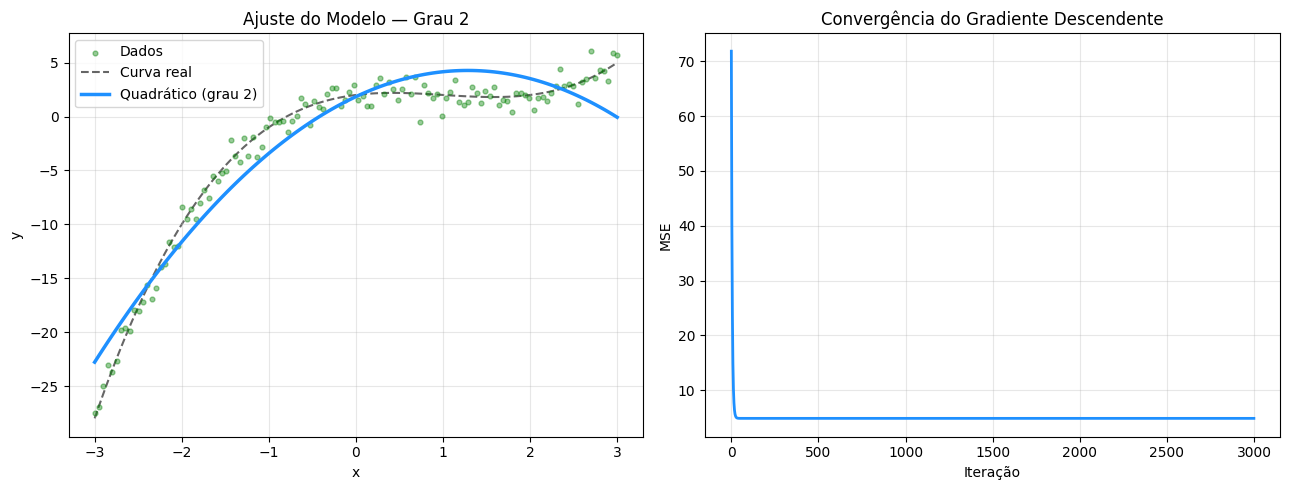

In [6]:
# ─── Altere 'grau_escolhido' para 1, 2 ou 3 e execute ───────────────────
grau_escolhido = 2    # <── mude aqui

theta, historico, Phi_norm = treinar(grau=grau_escolhido, alpha=0.05, n_iter=3000)

# ── Visualização ─────────────────────────────────────────────────────────
y_pred = Phi_norm @ theta
nomes_curtos = {1: "Linear (grau 1)", 2: "Quadrático (grau 2)", 3: "Cúbico (grau 3)"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Ajuste
axes[0].scatter(X, y, s=12, alpha=0.4, color='green', label='Dados', zorder=2)
axes[0].plot(X, y_true, 'k--', linewidth=1.5, alpha=0.6, label='Curva real', zorder=1)
axes[0].plot(X, y_pred, color='#1E90FF', linewidth=2.5,
             label=nomes_curtos[grau_escolhido], zorder=3)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title(f'Ajuste do Modelo — Grau {grau_escolhido}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Convergência
axes[1].plot(historico, color='#1E90FF', linewidth=2)
axes[1].set_xlabel('Iteração')
axes[1].set_ylabel('MSE')
axes[1].set_title('Convergência do Gradiente Descendente')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## <span style="color:#1E90FF;">7. Comparação dos Três Graus</span>

Treinamos os três modelos simultaneamente para comparar o MSE e a curva ajustada.

In [ ]:
# Treina os três modelos (verbose=False suprime a impressão individual)
theta1, hist1, Phi1 = treinar(1, alpha=0.05, n_iter=3000, verbose=False)
theta2, hist2, Phi2 = treinar(2, alpha=0.05, n_iter=3000, verbose=False)
theta3, hist3, Phi3 = treinar(3, alpha=0.05, n_iter=3000, verbose=False)

y1 = Phi1 @ theta1
y2 = Phi2 @ theta2
y3 = Phi3 @ theta3

mse1 = np.mean((y - y1) ** 2)
mse2 = np.mean((y - y2) ** 2)
mse3 = np.mean((y - y3) ** 2)

# ── Tabela de resultados ─────────────────────────────────────────────────
melhor = min([(mse1, 1), (mse2, 2), (mse3, 3)])

df_comp = pd.DataFrame(
    {"MSE": [mse1, mse2, mse3]},
    index=["Grau 1 (linear)", "Grau 2 (quadrático)", "Grau 3 (cúbico)"],
)

display(df_comp.style
    .format("{:.6f}")
    .set_caption(f"Melhor modelo: Grau {melhor[1]}  (MSE = {melhor[0]:.6f})")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "1em"), ("font-weight", "bold"), ("color", "#1E90FF")]},
        {"selector": "th",
         "props": [("background-color", "#1E90FF"), ("color", "white"), ("text-align", "center")]},
        {"selector": "td",
         "props": [("text-align", "right"), ("padding", "6px 16px")]},
    ])
    .highlight_min(axis=0, props="background-color:#d4edda; color:#155724;")
)

# ── Visualização comparativa ─────────────────────────────────────────────
cores  = ['#FF6347', '#FF8C00', '#1E90FF']
labels = [
    f'Grau 1 — MSE={mse1:.3f}',
    f'Grau 2 — MSE={mse2:.3f}',
    f'Grau 3 — MSE={mse3:.3f}',
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ajuste dos três modelos
axes[0].scatter(X, y, s=10, alpha=0.35, color='green', label='Dados', zorder=1)
axes[0].plot(X, y_true, 'k--', linewidth=1.5, alpha=0.5, label='Curva real', zorder=2)
for yi, cor, lbl in zip([y1, y2, y3], cores, labels):
    axes[0].plot(X, yi, color=cor, linewidth=2, label=lbl, zorder=3)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Comparação dos Três Modelos')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Convergência dos três modelos
for hist, cor, lbl in zip([hist1, hist2, hist3], cores, ['Grau 1', 'Grau 2', 'Grau 3']):
    axes[1].plot(hist, color=cor, linewidth=2, label=lbl)
axes[1].set_xlabel('Iteração')
axes[1].set_ylabel('MSE')
axes[1].set_title('Convergência por Grau')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## <span style="color:#1E90FF;">8. Conclusão</span>

| Modelo | Features $\phi(x)$ | Parâmetros | Quando usar |
|---|---|---|---|
| **Grau 1** | $[1,\, x]$ | 2 | Relação linear entre $x$ e $y$ |
| **Grau 2** | $[1,\, x,\, x^2]$ | 3 | Parábola — dados com máximo ou mínimo |
| **Grau 3** | $[1,\, x,\, x^2,\, x^3]$ | 4 | Inflexão — curvas assimétricas |

### O que mudou em relação às aulas anteriores?

- **Nada no gradiente descendente** — o algoritmo é idêntico ao da Aula 1.
- O que mudou foi a **matriz de design** $\Phi$: adicionamos colunas para $x^2$ e $x^3$.
- O gradiente agora atualiza **mais parâmetros** de uma vez — usando álgebra matricial.

### Observações importantes

> **Underfitting (grau 1):** o modelo é simples demais para capturar a curvatura dos dados.

> **Grau correto (grau 3):** como os dados foram gerados por um cúbico, esse grau captura a estrutura real.

> **Grau alto demais:** com dados reais, graus elevados podem gerar *overfitting* — o modelo decora o ruído.

### Conexão com redes neurais

> Este é o princípio por trás das redes neurais: cada camada aprende **transformações de features** cada vez mais complexas. O gradiente descendente é sempre o mesmo motor — apenas o número de parâmetros e a forma de $\Phi$ mudam.